In [1]:
import pandas as pd

In [2]:
from pathlib import Path
import json

ensayos_dir = Path("../ensayos")

rows = []
for txt_file in sorted(ensayos_dir.glob("*.txt")):
    distancia, nombre = txt_file.stem.split("_", 1)
    distancia_m = int(distancia.rstrip("M"))

    with txt_file.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            record = json.loads(line)
            record["archivo"] = txt_file.name
            record["distancia"] = distancia
            record["distancia_m"] = distancia_m
            record["nombre"] = nombre
            rows.append(record)

In [3]:
df_ensayos = pd.DataFrame(rows)

df_ensayos["fecha"] = pd.to_datetime(df_ensayos["fecha"], errors="coerce")

df_ensayos = df_ensayos[
    ["archivo", "distancia", "distancia_m", "nombre", "fecha", "rssi", "mensaje_recibido"]
].sort_values(["distancia_m", "nombre", "fecha"]).reset_index(drop=True)

print(f"Total de registros: {len(df_ensayos)}")

df_ensayos['archivo'] = df_ensayos['archivo'].str.lower()

df_ensayos.head()

Total de registros: 1146


,archivo,distancia,distancia_m,nombre,fecha,rssi,mensaje_recibido
0,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:08,-76,Envio #0
1,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:10,-80,Envio #1
2,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:12,-81,Envio #2
3,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:14,-86,Envio #3
4,5m_antena_chica.txt,5M,5,ANTENA_CHICA,2026-03-05 16:40:16,-83,Envio #4


In [4]:
# Permite re-ejecutar la celda sin depender de distancia_m
col_distancia = "distancia_m" if "distancia_m" in df_ensayos.columns else "distancia"

df_ensayos = (
    df_ensayos
    .assign(
        distancia=lambda d: pd.to_numeric(d[col_distancia], errors="coerce").astype("Int64"),
        nombre=lambda d: d["nombre"].astype(str).str.replace("_", " ", regex=False).str.lower(),
        mensaje_recibido=lambda d: pd.to_numeric(
            d["mensaje_recibido"].astype(str).str.extract(r"(\d+)", expand=False),
            errors="coerce"
        ).astype("Int64"),
    )
    .drop(columns=["distancia_m"], errors="ignore")
)

df_ensayos.head()

,archivo,distancia,nombre,fecha,rssi,mensaje_recibido
0,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:08,-76,0
1,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:10,-80,1
2,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:12,-81,2
3,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:14,-86,3
4,5m_antena_chica.txt,5,antena chica,2026-03-05 16:40:16,-83,4


In [5]:
# Orden cronologico por archivo para calcular el tiempo hacia n+1
df_ensayos = df_ensayos.sort_values(["archivo", "fecha"]).reset_index(drop=True)

# Delta en segundos hacia el siguiente registro dentro del mismo archivo
# (sin crear la columna delta_n1)
df_ensayos["delta_n1_seg"] = (
    df_ensayos.groupby("archivo")["fecha"].shift(-1) - df_ensayos["fecha"]
).dt.total_seconds()

print(f"Total de registros: {len(df_ensayos)}")


# Vista final sin las columnas fecha ni delta_n1
df_ensayos[[
    "archivo", "distancia", "nombre", "rssi", "mensaje_recibido", "delta_n1_seg"
]].sample(5)

Total de registros: 1146


,archivo,distancia,nombre,rssi,mensaje_recibido,delta_n1_seg
209,100m_antena_grande.txt,100,antena grande,-91,526,2.0
144,100m_antena_chica.txt,100,antena chica,-94,1207,2.0
977,5m_antena_grande.txt,5,antena grande,-70,433,2.0
119,100m_antena_chica.txt,100,antena chica,-98,1182,2.0
578,50m_antena_grande.txt,50,antena grande,-81,1332,2.0


In [6]:
# Metricas de recepcion por archivo
periodo_envio_obj_seg = 2.0

tasa_recepcion = (
    df_ensayos.groupby("archivo", as_index=False)
    .agg(
        distancia_m=("distancia", "first"),
        tipo_antena=("nombre", "first"),
        mensajes_recibidos=("mensaje_recibido", "count"),
        tiempo_observado_seg=("delta_n1_seg", "sum"),
        intervalo_prom_seg=("delta_n1_seg", "mean"),
        intervalo_mediana_seg=("delta_n1_seg", "median"),
        intervalo_std_seg=("delta_n1_seg", "std"),
        intervalo_p95_seg=("delta_n1_seg", lambda s: s.quantile(0.95)),
        rssi_prom=("rssi", "mean"),
        rssi_min=("rssi", "min"),
        rssi_max=("rssi", "max"),
    )
    .sort_values(["distancia_m", "tipo_antena"])
    .reset_index(drop=True)
)

# Muestras esperadas: se estima por ventana de tiempo observada y periodo objetivo de envio
# Se suma 1 para compensar que hay N-1 intervalos entre N mensajes
tasa_recepcion["mensajes_esperados"] = (
    (tasa_recepcion["tiempo_observado_seg"] / periodo_envio_obj_seg).round().astype("Int64") + 1
)

tasa_recepcion["mensajes_perdidos_est"] = (
    (tasa_recepcion["mensajes_esperados"] - tasa_recepcion["mensajes_recibidos"]) 
    .clip(lower=0)
    .astype("Int64")
)

denom_tiempo = tasa_recepcion["tiempo_observado_seg"].replace(0, pd.NA)

tasa_recepcion["pct_entrega"] = (
    100 * tasa_recepcion["mensajes_recibidos"] / tasa_recepcion["mensajes_esperados"]
).round(2)

tasa_recepcion["tasa_rx_msg_s"] = (
    tasa_recepcion["mensajes_recibidos"] / denom_tiempo
).round(3)

tasa_recepcion["tasa_rx_msg_min"] = (
    60 * tasa_recepcion["mensajes_recibidos"] / denom_tiempo
).round(2)

tasa_recepcion["desfase_intervalo_pct"] = (
    100 * (tasa_recepcion["intervalo_prom_seg"] - periodo_envio_obj_seg) / periodo_envio_obj_seg
).round(2)

tasa_recepcion["periodo_envio_obj_seg"] = periodo_envio_obj_seg

tasa_recepcion

,archivo,distancia_m,tipo_antena,mensajes_recibidos,tiempo_observado_seg,intervalo_prom_seg,intervalo_mediana_seg,intervalo_std_seg,intervalo_p95_seg,rssi_prom,rssi_min,rssi_max,mensajes_esperados,mensajes_perdidos_est,pct_entrega,tasa_rx_msg_s,tasa_rx_msg_min,desfase_intervalo_pct,periodo_envio_obj_seg
0,5m_antena_chica.txt,5,antena chica,166,343.0,2.078788,2.0,0.270228,3.0,-74.897590,-94,-67,173,7,95.95,0.484,29.04,3.94,2.0
1,5m_antena_grande.txt,5,antena grande,116,241.0,2.095652,2.0,0.374023,3.0,-71.215517,-84,-57,121,5,95.87,0.481,28.88,4.78,2.0
2,5m_sin_antena.txt,5,sin antena,129,297.0,2.320312,2.0,2.410390,3.0,-120.046512,-121,-113,149,20,86.58,0.434,26.06,16.02,2.0
3,50m_antena_chica.txt,50,antena chica,176,363.0,2.074286,2.0,0.262988,3.0,-82.278409,-104,-70,183,7,96.17,0.485,29.09,3.71,2.0
4,50m_antena_grande.txt,50,antena grande,185,382.0,2.076087,2.0,0.265861,3.0,-81.172973,-106,-71,192,7,96.35,0.484,29.06,3.80,2.0
5,100m_antena_chica.txt,100,antena chica,160,334.0,2.100629,2.0,0.341163,3.0,-94.968750,-104,-82,168,8,95.24,0.479,28.74,5.03,2.0
6,100m_antena_grande.txt,100,antena grande,157,328.0,2.102564,2.0,0.344158,3.0,-88.936306,-103,-81,165,8,95.15,0.479,28.72,5.13,2.0
7,500m_antena_grande.txt,500,antena grande,57,163.0,2.910714,2.0,2.609610,6.5,-101.350877,-106,-96,83,26,68.67,0.35,20.98,45.54,2.0


In [7]:
# ============================================================
# Configuración global – estilo paper (IEEE / académico)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy import stats

plt.rcParams.update({
    # Fuentes
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.6",
    # Líneas y marcadores
    "lines.linewidth": 1.2,
    "lines.markersize": 5,
    # Ejes
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.5,
    # Figura
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.figsize": (6, 3.8),
    "figure.constrained_layout.use": True,
})

# Paleta y etiquetas consistentes
ANTENA_ORDER = ["sin antena", "antena chica", "antena grande"]
ANTENA_LABELS = {"sin antena": "Sin antena", "antena chica": "Antena corta", "antena grande": "Antena larga"}
ANTENA_COLORS = {"sin antena": "#1b9e77", "antena chica": "#d95f02", "antena grande": "#7570b3"}
ANTENA_MARKERS = {"sin antena": "s", "antena chica": "^", "antena grande": "o"}
DIST_ORDER = sorted(df_ensayos["distancia"].dropna().unique())

print("Estilo paper configurado ✓")

Estilo paper configurado ✓


## 1. Distribución de RSSI — Boxplot por distancia y tipo de antena

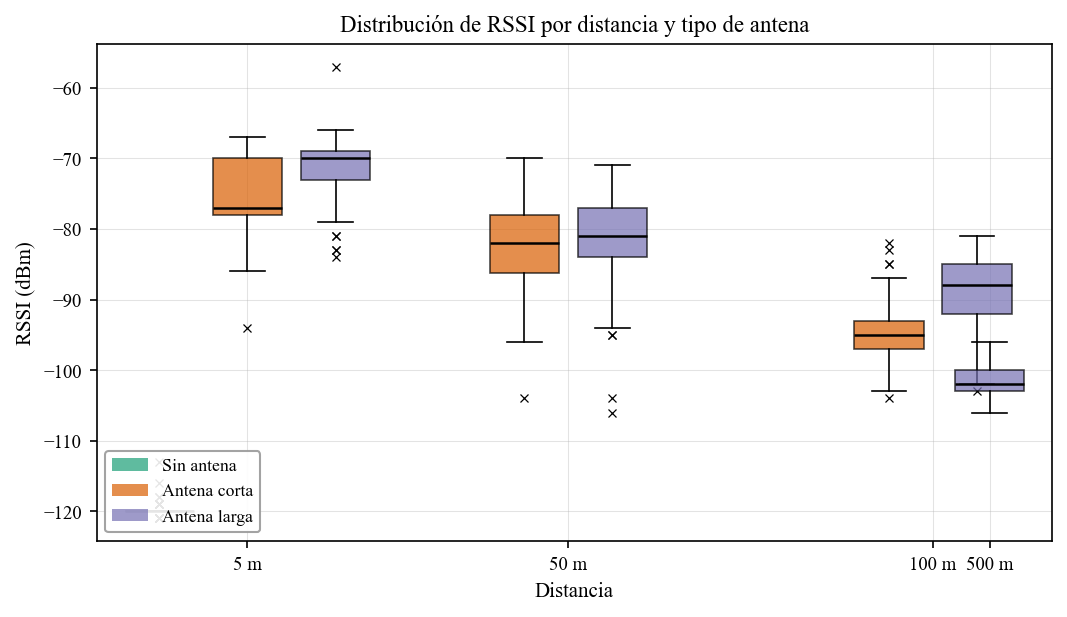

In [8]:
# --- Fig 1: Boxplot RSSI por distancia y tipo de antena ---
fig, ax = plt.subplots(figsize=(7, 4))

positions = []
tick_positions = []
tick_labels = []
group_width = 0.7
gap = 1.5
colors_list = []

for i, dist in enumerate(DIST_ORDER):
    antenas_in_dist = df_ensayos[df_ensayos["distancia"] == dist]["nombre"].unique()
    antenas_in_dist = [a for a in ANTENA_ORDER if a in antenas_in_dist]
    n = len(antenas_in_dist)
    center = i * (n * group_width + gap)
    tick_positions.append(center + (n - 1) * group_width / 2)
    tick_labels.append(f"{dist} m")

    for j, ant in enumerate(antenas_in_dist):
        data = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]["rssi"]
        pos = center + j * group_width
        bp = ax.boxplot(data, positions=[pos], widths=0.55, patch_artist=True,
                        boxprops=dict(facecolor=ANTENA_COLORS[ant], alpha=0.7, linewidth=0.8),
                        medianprops=dict(color="black", linewidth=1.2),
                        whiskerprops=dict(linewidth=0.8),
                        capprops=dict(linewidth=0.8),
                        flierprops=dict(marker="x", markersize=4, markeredgewidth=0.6))

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_ylabel("RSSI (dBm)")
ax.set_xlabel("Distancia")
ax.set_title("Distribución de RSSI por distancia y tipo de antena")

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=ANTENA_COLORS[a], alpha=0.7, label=ANTENA_LABELS[a]) for a in ANTENA_ORDER]
ax.legend(handles=legend_elements, loc="lower left")
plt.show()

## 2. Violin plot — RSSI por distancia y tipo de antena

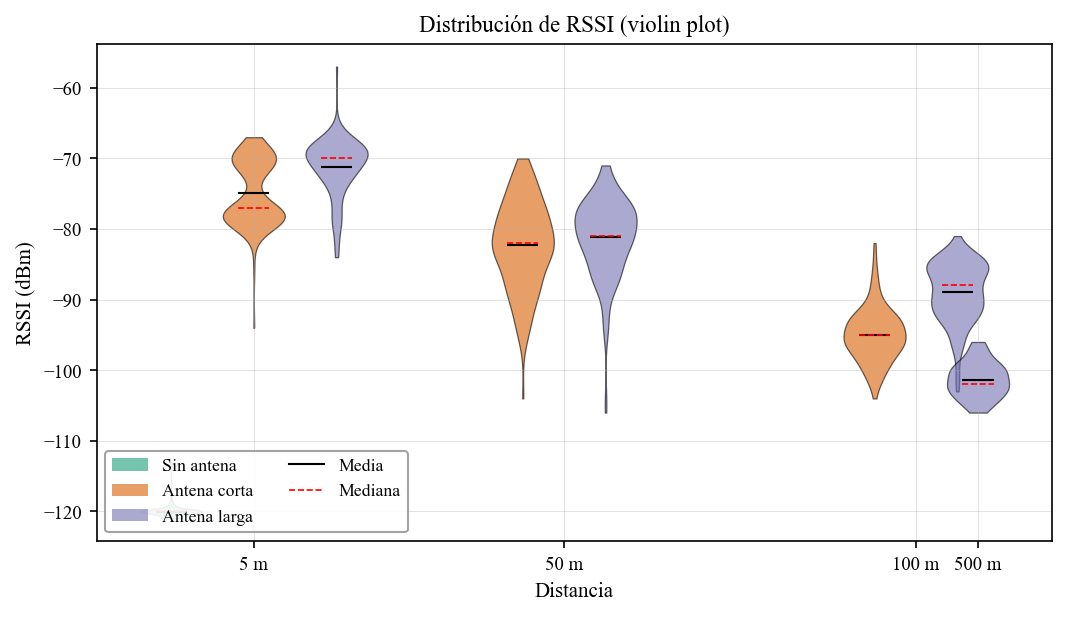

In [9]:
# --- Fig 2: Violin plot RSSI ---
fig, ax = plt.subplots(figsize=(7, 4))

vp_positions = []
vp_data = []
vp_colors = []
tick_positions2 = []
tick_labels2 = []
group_width = 0.8
gap = 1.8

for i, dist in enumerate(DIST_ORDER):
    antenas_in_dist = [a for a in ANTENA_ORDER if a in df_ensayos[df_ensayos["distancia"] == dist]["nombre"].unique()]
    n = len(antenas_in_dist)
    center = i * (n * group_width + gap)
    tick_positions2.append(center + (n - 1) * group_width / 2)
    tick_labels2.append(f"{dist} m")

    for j, ant in enumerate(antenas_in_dist):
        data = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]["rssi"].values
        pos = center + j * group_width
        vp_positions.append(pos)
        vp_data.append(data)
        vp_colors.append(ANTENA_COLORS[ant])

parts = ax.violinplot(vp_data, positions=vp_positions, widths=0.6, showmeans=True, showmedians=True, showextrema=False)

for pc, color in zip(parts["bodies"], vp_colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
    pc.set_edgecolor("black")
    pc.set_linewidth(0.6)

parts["cmeans"].set_color("black")
parts["cmeans"].set_linewidth(1.0)
parts["cmedians"].set_color("red")
parts["cmedians"].set_linewidth(0.8)
parts["cmedians"].set_linestyle("--")

ax.set_xticks(tick_positions2)
ax.set_xticklabels(tick_labels2)
ax.set_ylabel("RSSI (dBm)")
ax.set_xlabel("Distancia")
ax.set_title("Distribución de RSSI (violin plot)")

legend_elements = [Patch(facecolor=ANTENA_COLORS[a], alpha=0.6, label=ANTENA_LABELS[a]) for a in ANTENA_ORDER]
legend_elements += [plt.Line2D([0],[0], color="black", lw=1, label="Media"),
                    plt.Line2D([0],[0], color="red", lw=0.8, ls="--", label="Mediana")]
ax.legend(handles=legend_elements, loc="lower left", ncol=2)
plt.show()

## 3. RSSI medio vs distancia (con barras de error)

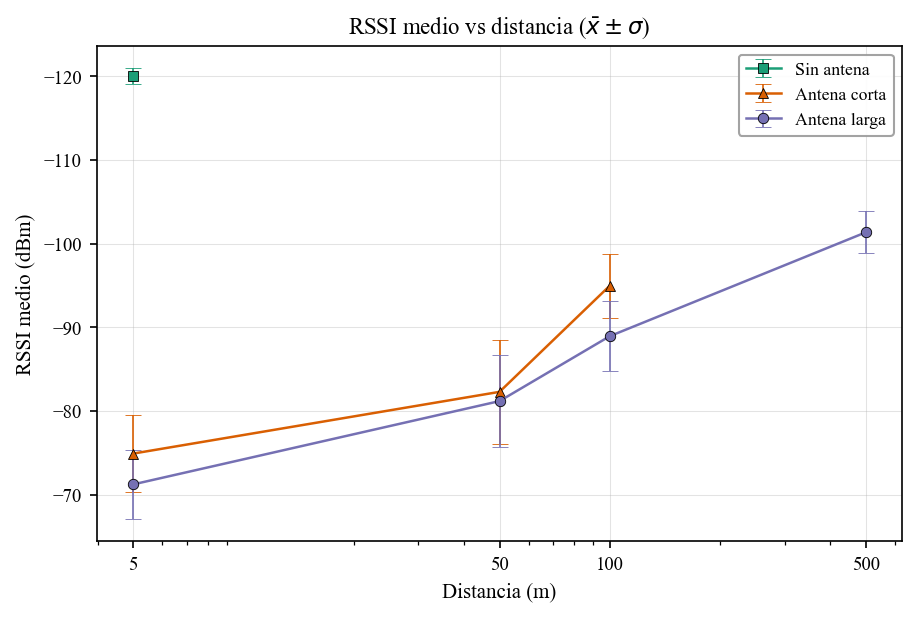

In [10]:
# --- Fig 3: RSSI medio vs distancia con error bars (± 1 σ) ---
fig, ax = plt.subplots(figsize=(6, 4))

for ant in ANTENA_ORDER:
    sub = df_ensayos[df_ensayos["nombre"] == ant]
    if sub.empty:
        continue
    stats_df = sub.groupby("distancia")["rssi"].agg(["mean", "std"]).reindex(DIST_ORDER).dropna()
    ax.errorbar(
        stats_df.index, stats_df["mean"], yerr=stats_df["std"],
        fmt=ANTENA_MARKERS[ant] + "-",
        color=ANTENA_COLORS[ant],
        label=ANTENA_LABELS[ant],
        capsize=4, capthick=0.8, elinewidth=0.8,
        markeredgecolor="black", markeredgewidth=0.4,
    )

ax.set_xscale("log")
ax.set_xticks(DIST_ORDER)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Distancia (m)")
ax.set_ylabel("RSSI medio (dBm)")
ax.set_title("RSSI medio vs distancia ($\\bar{x} \\pm \\sigma$)")
ax.legend()
ax.invert_yaxis()
plt.show()

## 4. RSSI medio vs distancia (escala lineal) con modelo log-distance

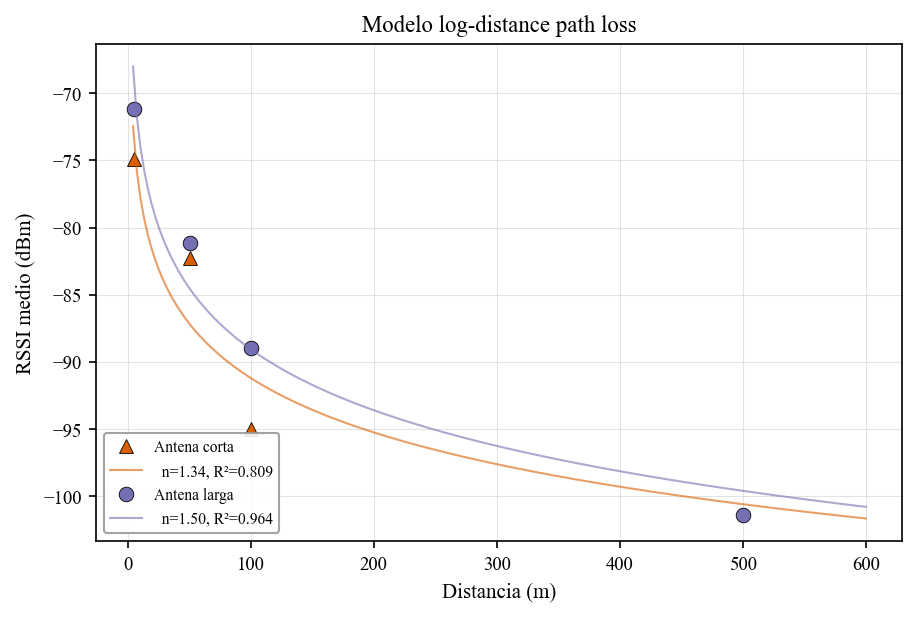

In [11]:
# --- Fig 4: RSSI vs distancia con ajuste log-distance path loss ---
fig, ax = plt.subplots(figsize=(6, 4))

for ant in ANTENA_ORDER:
    sub = df_ensayos[df_ensayos["nombre"] == ant]
    if sub.empty or sub["distancia"].nunique() < 2:
        continue
    stats_df = sub.groupby("distancia")["rssi"].mean()

    # Ajuste lineal: RSSI = A - 10·n·log10(d)  →  RSSI vs log10(d)
    x = np.log10(stats_df.index.values.astype(float))
    y = stats_df.values
    slope, intercept, r, p, se = scipy_linregress = __import__("scipy.stats", fromlist=["linregress"]).linregress(x, y)

    d_fit = np.linspace(min(DIST_ORDER) * 0.8, max(DIST_ORDER) * 1.2, 200)
    rssi_fit = intercept + slope * np.log10(d_fit)

    ax.plot(stats_df.index, y, ANTENA_MARKERS[ant],
            color=ANTENA_COLORS[ant], markeredgecolor="black", markeredgewidth=0.4,
            markersize=7, label=f"{ANTENA_LABELS[ant]}")
    ax.plot(d_fit, rssi_fit, "-", color=ANTENA_COLORS[ant], alpha=0.6, linewidth=1.0,
            label=f"  n={-slope/10:.2f}, R²={r**2:.3f}")

ax.set_xlabel("Distancia (m)")
ax.set_ylabel("RSSI medio (dBm)")
ax.set_title("Modelo log-distance path loss")
ax.legend(fontsize=7.5, loc="lower left")
plt.show()

## 5. Serie temporal de RSSI por ensayo

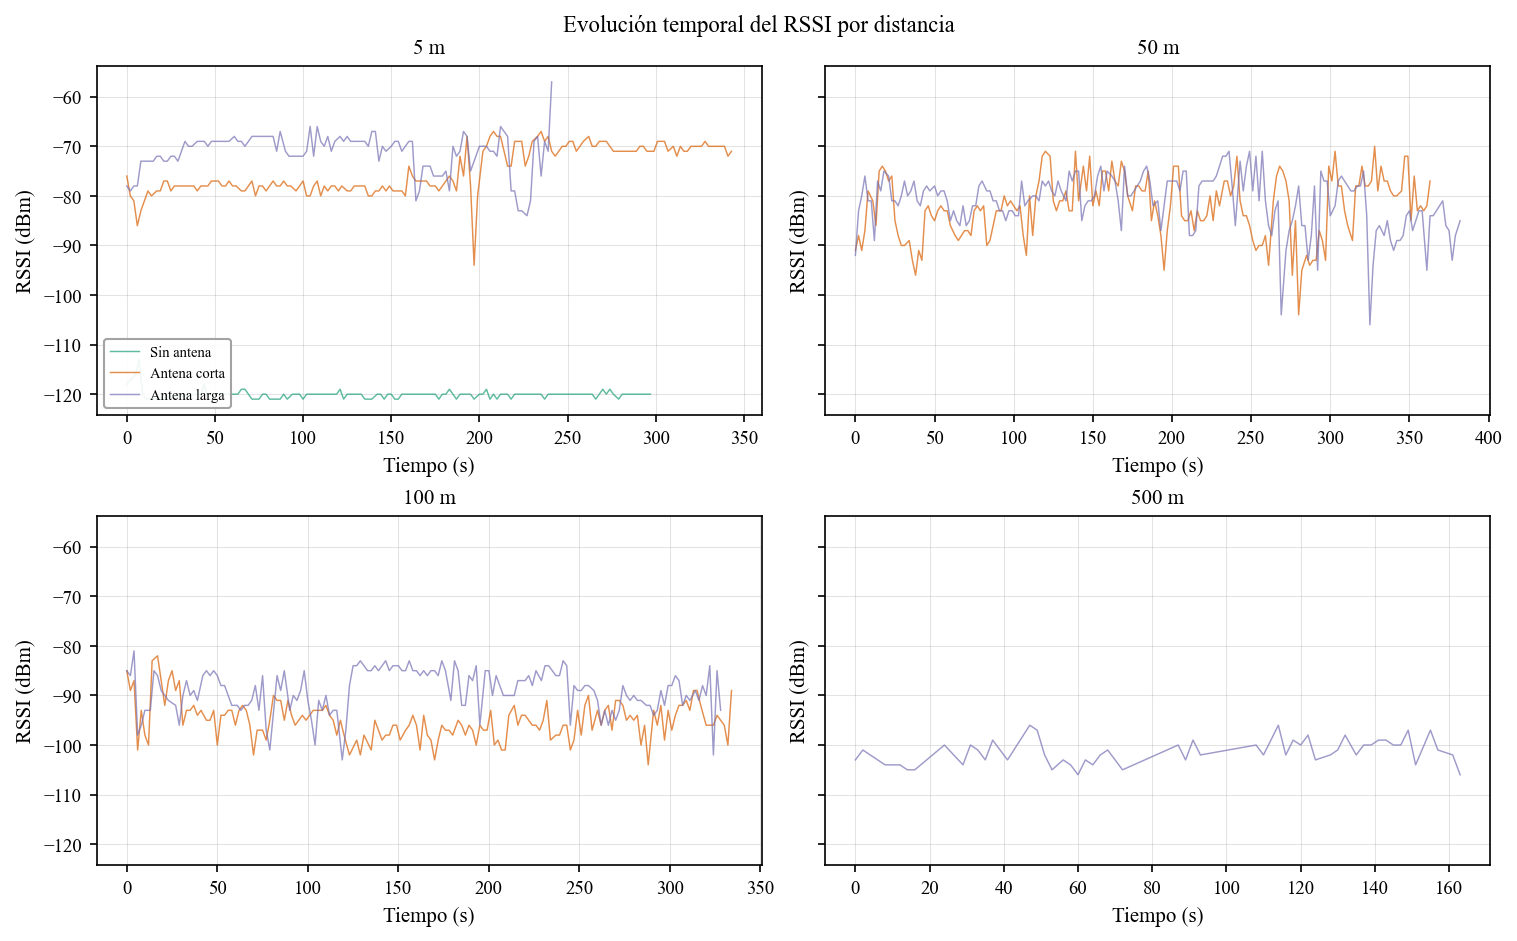

In [12]:
# --- Fig 5: Serie temporal RSSI (un subplot por distancia) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=True)
axes = axes.flatten()

for idx, dist in enumerate(DIST_ORDER):
    ax = axes[idx]
    sub_dist = df_ensayos[df_ensayos["distancia"] == dist]
    for ant in ANTENA_ORDER:
        sub = sub_dist[sub_dist["nombre"] == ant]
        if sub.empty:
            continue
        t = (sub["fecha"] - sub["fecha"].iloc[0]).dt.total_seconds()
        ax.plot(t, sub["rssi"], color=ANTENA_COLORS[ant], alpha=0.7,
                linewidth=0.7, label=ANTENA_LABELS[ant])
    ax.set_title(f"{dist} m", fontsize=10)
    ax.set_ylabel("RSSI (dBm)")
    ax.set_xlabel("Tiempo (s)")
    if idx == 0:
        ax.legend(fontsize=7, loc="lower left")

fig.suptitle("Evolución temporal del RSSI por distancia", fontsize=11, y=1.02)
plt.show()

## 6. Histogramas de RSSI por configuración

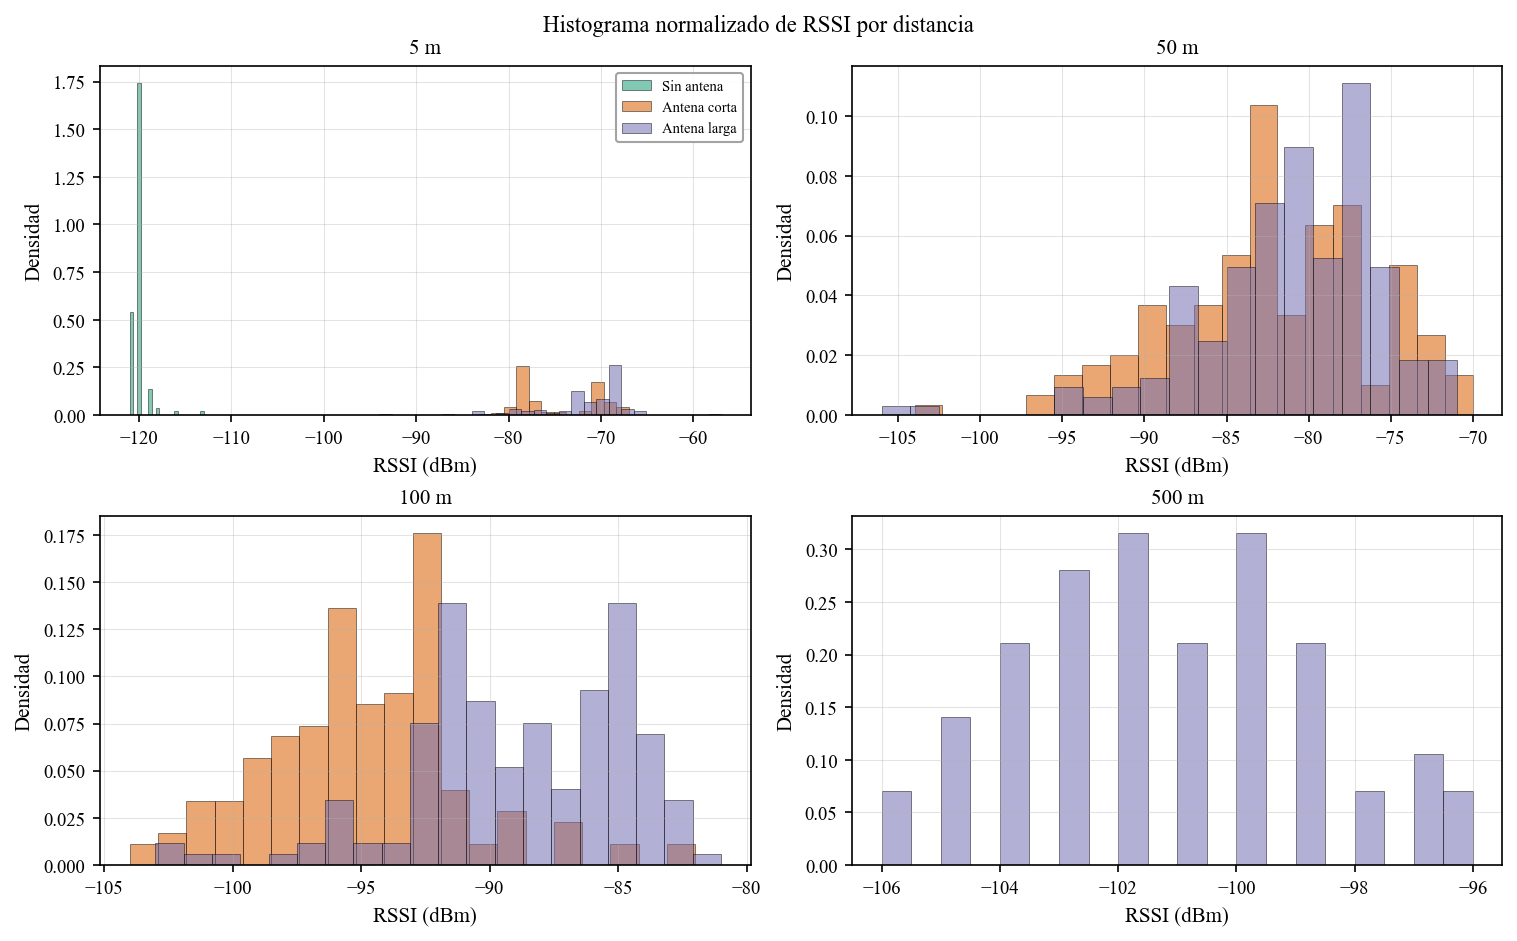

In [13]:
# --- Fig 6: Histogramas superpuestos por distancia ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharey=False)
axes = axes.flatten()

for idx, dist in enumerate(DIST_ORDER):
    ax = axes[idx]
    sub_dist = df_ensayos[df_ensayos["distancia"] == dist]
    for ant in ANTENA_ORDER:
        sub = sub_dist[sub_dist["nombre"] == ant]
        if sub.empty:
            continue
        ax.hist(sub["rssi"], bins=20, alpha=0.55, color=ANTENA_COLORS[ant],
                edgecolor="black", linewidth=0.4, label=ANTENA_LABELS[ant], density=True)
    ax.set_title(f"{dist} m", fontsize=10)
    ax.set_xlabel("RSSI (dBm)")
    ax.set_ylabel("Densidad")
    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle("Histograma normalizado de RSSI por distancia", fontsize=11, y=1.02)
plt.show()

## 7. CDF empírica de RSSI

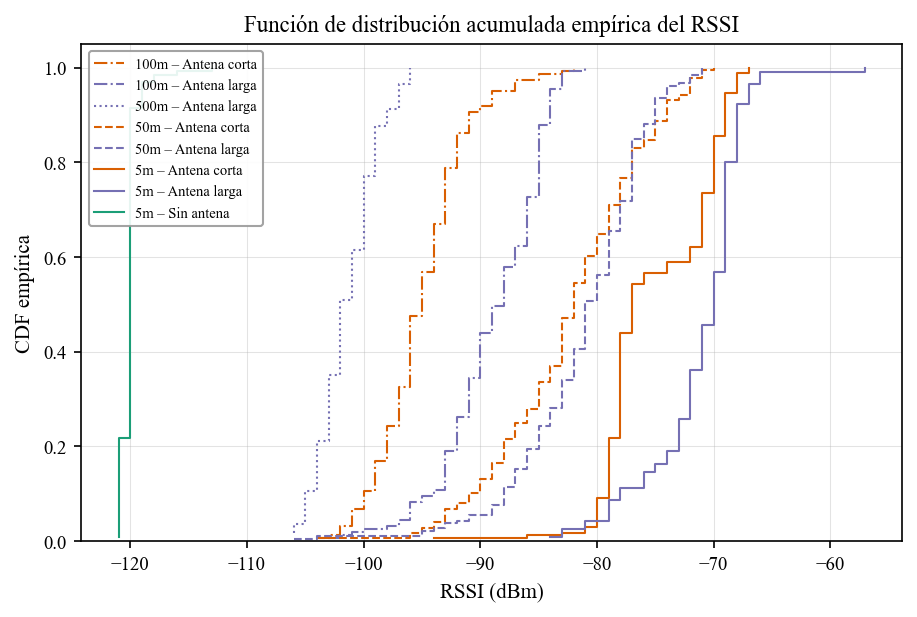

In [14]:
# --- Fig 7a: ECDF de RSSI por archivo (todas las curvas) ---
fig, ax = plt.subplots(figsize=(6, 4))

linestyles = {5: "-", 50: "--", 100: "-.", 500: ":"}
for archivo in sorted(df_ensayos["archivo"].unique()):
    sub = df_ensayos[df_ensayos["archivo"] == archivo]
    ant = sub["nombre"].iloc[0]
    dist = sub["distancia"].iloc[0]
    rssi_sorted = np.sort(sub["rssi"].values)
    ecdf = np.arange(1, len(rssi_sorted) + 1) / len(rssi_sorted)
    ax.step(rssi_sorted, ecdf, where="post",
            color=ANTENA_COLORS[ant], linestyle=linestyles.get(dist, "-"),
            linewidth=1.0, label=f"{dist}m – {ANTENA_LABELS[ant]}")

ax.set_xlabel("RSSI (dBm)")
ax.set_ylabel("CDF empírica")
ax.set_title("Función de distribución acumulada empírica del RSSI")
ax.legend(fontsize=7, loc="upper left")
ax.set_ylim(0, 1.05)
plt.show()

## 8. Heatmap — RSSI medio (distancia × tipo de antena)

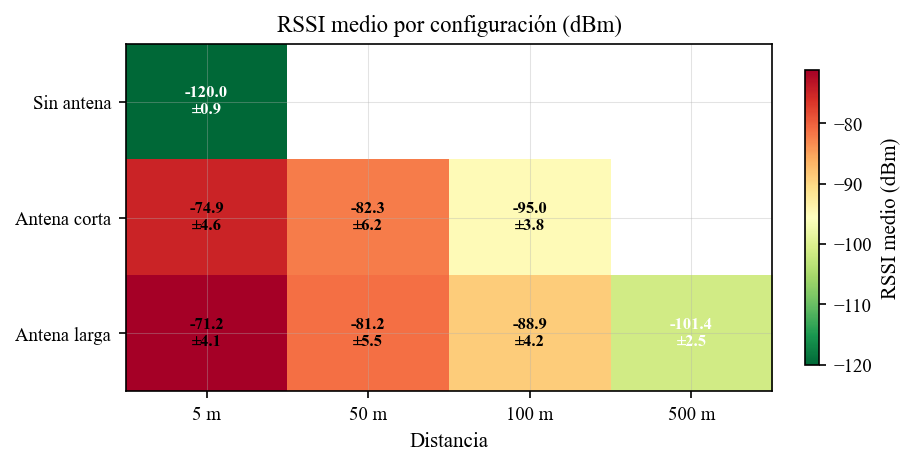

In [15]:
# --- Fig 8: Heatmap RSSI medio ---
pivot_mean = df_ensayos.pivot_table(values="rssi", index="nombre", columns="distancia", aggfunc="mean")
pivot_mean = pivot_mean.reindex(ANTENA_ORDER).reindex(columns=DIST_ORDER)
pivot_std = df_ensayos.pivot_table(values="rssi", index="nombre", columns="distancia", aggfunc="std")
pivot_std = pivot_std.reindex(ANTENA_ORDER).reindex(columns=DIST_ORDER)

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(pivot_mean.values, cmap="RdYlGn_r", aspect="auto")
cbar = fig.colorbar(im, ax=ax, shrink=0.85, label="RSSI medio (dBm)")

# Anotaciones con media ± std
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        val = pivot_mean.iloc[i, j]
        std = pivot_std.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.1f}\n±{std:.1f}", ha="center", va="center",
                    fontsize=8, fontweight="bold",
                    color="white" if val < -95 else "black")

ax.set_xticks(range(len(DIST_ORDER)))
ax.set_xticklabels([f"{d} m" for d in DIST_ORDER])
ax.set_yticks(range(len(ANTENA_ORDER)))
ax.set_yticklabels([ANTENA_LABELS[a] for a in ANTENA_ORDER])
ax.set_xlabel("Distancia")
ax.set_title("RSSI medio por configuración (dBm)")
plt.show()

## 9. Tasa de entrega de paquetes (PDR)

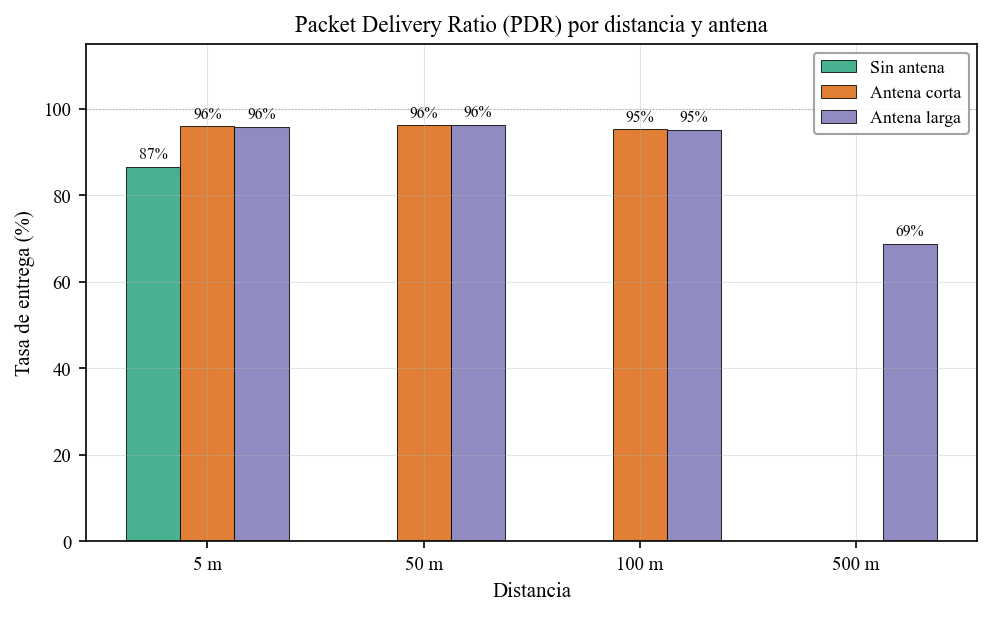

In [16]:
# --- Fig 9: Tasa de entrega (PDR) como barras agrupadas ---
fig, ax = plt.subplots(figsize=(6.5, 4))

bar_width = 0.25
x_pos = np.arange(len(DIST_ORDER))

for i, ant in enumerate(ANTENA_ORDER):
    pdrs = []
    for dist in DIST_ORDER:
        mask = (tasa_recepcion["distancia_m"] == dist) & (tasa_recepcion["tipo_antena"] == ant)
        row = tasa_recepcion[mask]
        if row.empty:
            pdrs.append(0)
        else:
            pdrs.append(row["pct_entrega"].values[0])
    bars = ax.bar(x_pos + i * bar_width, pdrs, bar_width,
                  color=ANTENA_COLORS[ant], edgecolor="black", linewidth=0.5,
                  label=ANTENA_LABELS[ant], alpha=0.8)
    # Anotaciones
    for bar, pdr in zip(bars, pdrs):
        if pdr > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{pdr:.0f}%", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels([f"{d} m" for d in DIST_ORDER])
ax.set_ylabel("Tasa de entrega (%)")
ax.set_xlabel("Distancia")
ax.set_title("Packet Delivery Ratio (PDR) por distancia y antena")
ax.set_ylim(0, 115)
ax.legend(loc="upper right")
ax.axhline(y=100, color="gray", linestyle=":", linewidth=0.6, alpha=0.5)
plt.show()

## 10. Mensajes recibidos vs esperados (stacked bar)

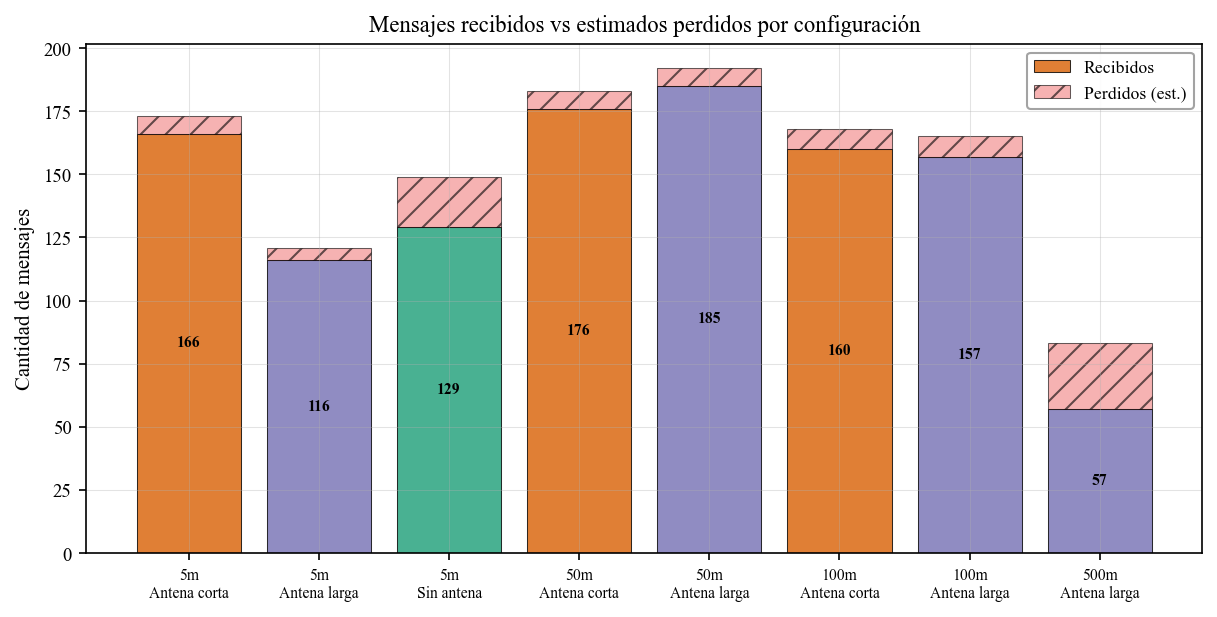

In [17]:
# --- Fig 10: Mensajes recibidos vs perdidos (stacked) ---
fig, ax = plt.subplots(figsize=(8, 4))

labels = []
recibidos = []
perdidos = []
colors = []

for _, row in tasa_recepcion.sort_values(["distancia_m", "tipo_antena"]).iterrows():
    labels.append(f"{row['distancia_m']}m\n{ANTENA_LABELS.get(row['tipo_antena'], row['tipo_antena'])}")
    recibidos.append(row["mensajes_recibidos"])
    perdidos.append(row["mensajes_perdidos_est"])
    colors.append(ANTENA_COLORS.get(row["tipo_antena"], "gray"))

x = np.arange(len(labels))
bars1 = ax.bar(x, recibidos, color=colors, edgecolor="black", linewidth=0.5, alpha=0.8, label="Recibidos")
bars2 = ax.bar(x, perdidos, bottom=recibidos, color="lightcoral", edgecolor="black",
               linewidth=0.5, alpha=0.6, hatch="//", label="Perdidos (est.)")

for bar, val in zip(bars1, recibidos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            str(val), ha="center", va="center", fontsize=7.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("Cantidad de mensajes")
ax.set_title("Mensajes recibidos vs estimados perdidos por configuración")
ax.legend(loc="upper right")
plt.show()

## 11. Jitter — Distribución del intervalo entre mensajes

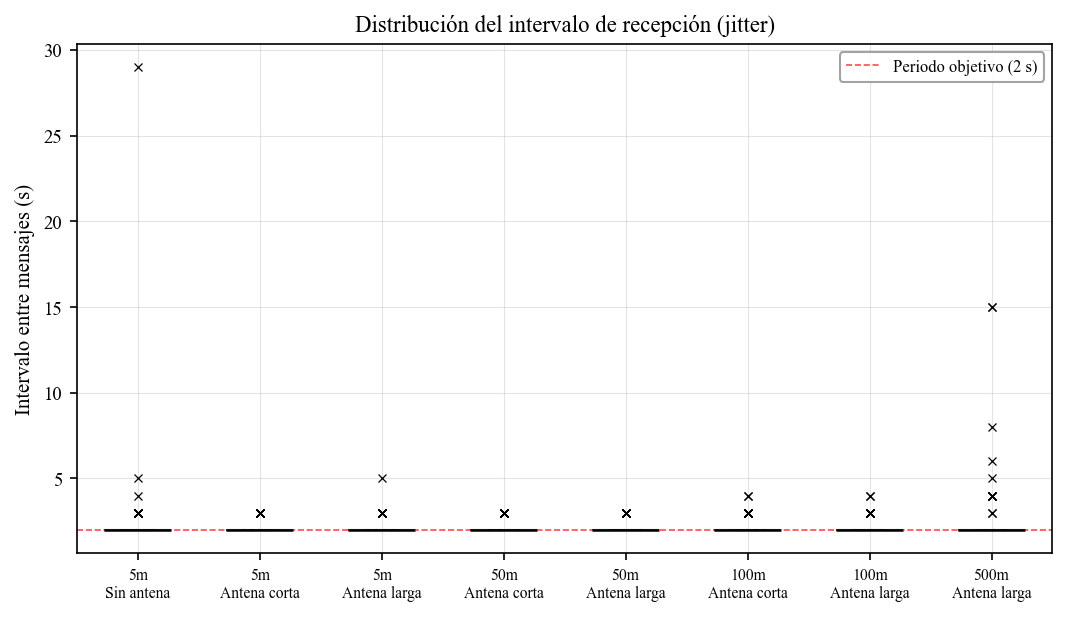

In [18]:
# --- Fig 11: Boxplot del intervalo entre mensajes (jitter) ---
fig, ax = plt.subplots(figsize=(7, 4))

box_data = []
box_labels = []
box_colors = []

for dist in DIST_ORDER:
    for ant in ANTENA_ORDER:
        sub = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]
        delta = sub["delta_n1_seg"].dropna()
        if delta.empty:
            continue
        box_data.append(delta.values)
        box_labels.append(f"{dist}m\n{ANTENA_LABELS[ant]}")
        box_colors.append(ANTENA_COLORS[ant])

bp = ax.boxplot(box_data, patch_artist=True, widths=0.55,
                medianprops=dict(color="black", linewidth=1.2),
                whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8),
                flierprops=dict(marker="x", markersize=4, markeredgewidth=0.6))

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=2.0, color="red", linestyle="--", linewidth=0.8, alpha=0.7, label="Periodo objetivo (2 s)")
ax.set_xticklabels(box_labels, fontsize=7.5)
ax.set_ylabel("Intervalo entre mensajes (s)")
ax.set_title("Distribución del intervalo de recepción (jitter)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## 12. RSSI vs número de mensaje (tendencia temporal / drift)

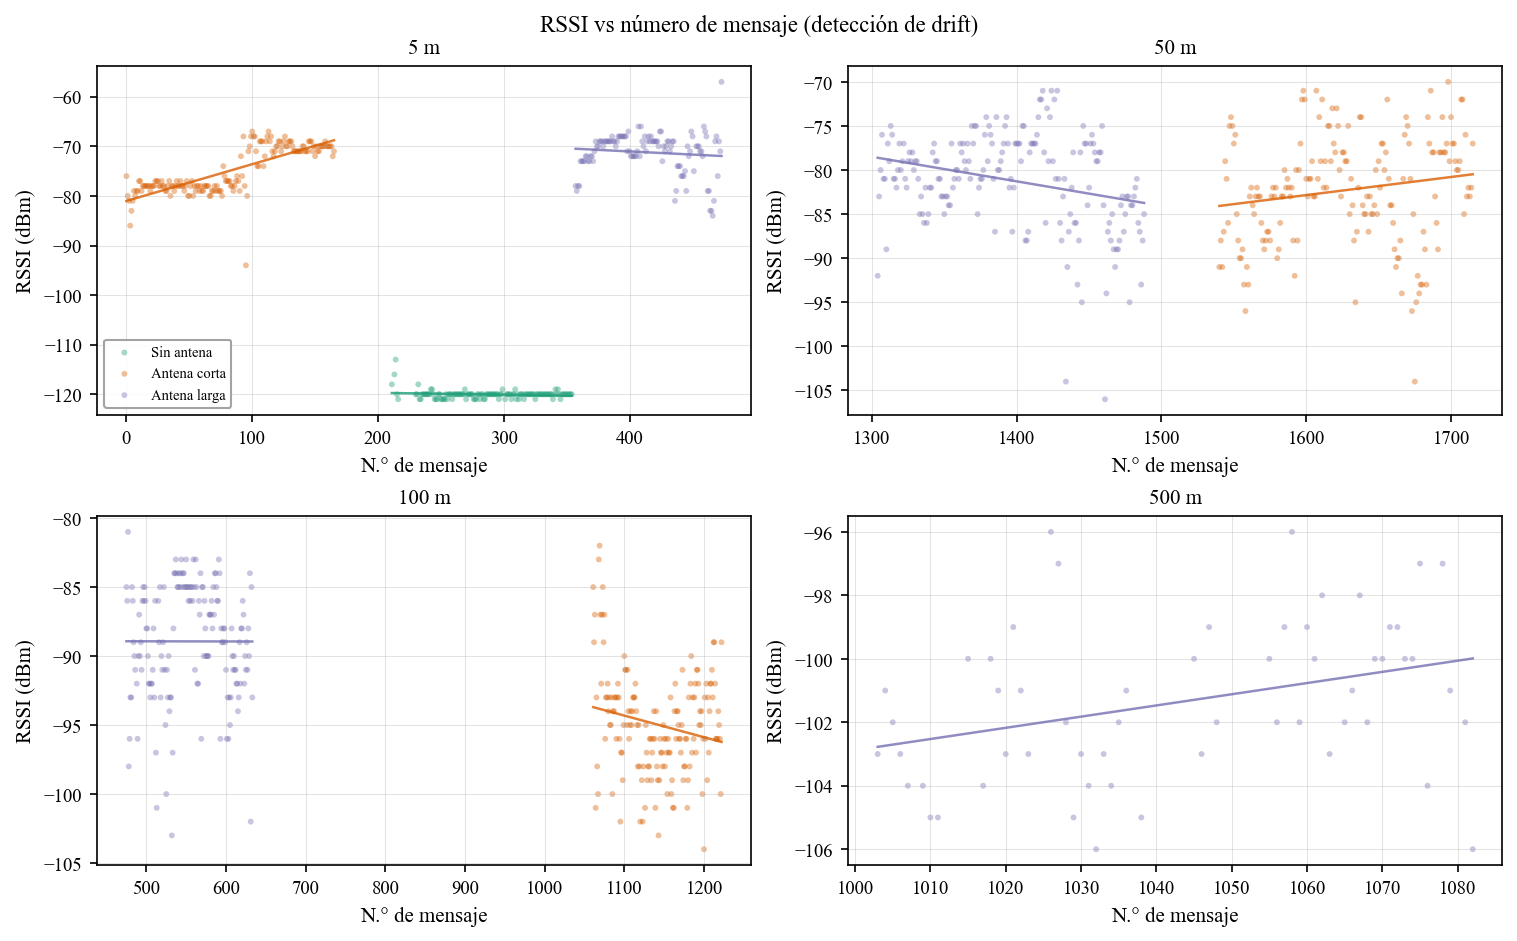

In [19]:
# --- Fig 12: Scatter RSSI vs # mensaje con tendencia lineal ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False)
axes = axes.flatten()

for idx, dist in enumerate(DIST_ORDER):
    ax = axes[idx]
    sub_dist = df_ensayos[df_ensayos["distancia"] == dist]
    for ant in ANTENA_ORDER:
        sub = sub_dist[sub_dist["nombre"] == ant].dropna(subset=["mensaje_recibido"])
        if sub.empty:
            continue
        x = sub["mensaje_recibido"].values.astype(float)
        y = sub["rssi"].values.astype(float)
        ax.scatter(x, y, s=8, alpha=0.4, color=ANTENA_COLORS[ant], label=ANTENA_LABELS[ant],
                   edgecolors="none")
        # Tendencia
        if len(x) > 2:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            x_fit = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_fit, p(x_fit), color=ANTENA_COLORS[ant], linewidth=1.2, alpha=0.8)

    ax.set_title(f"{dist} m", fontsize=10)
    ax.set_xlabel("N.° de mensaje")
    ax.set_ylabel("RSSI (dBm)")
    if idx == 0:
        ax.legend(fontsize=7, loc="lower left")

fig.suptitle("RSSI vs número de mensaje (detección de drift)", fontsize=11, y=1.02)
plt.show()

## 13. Comparación RSSI entre antenas a misma distancia (paired bar chart)

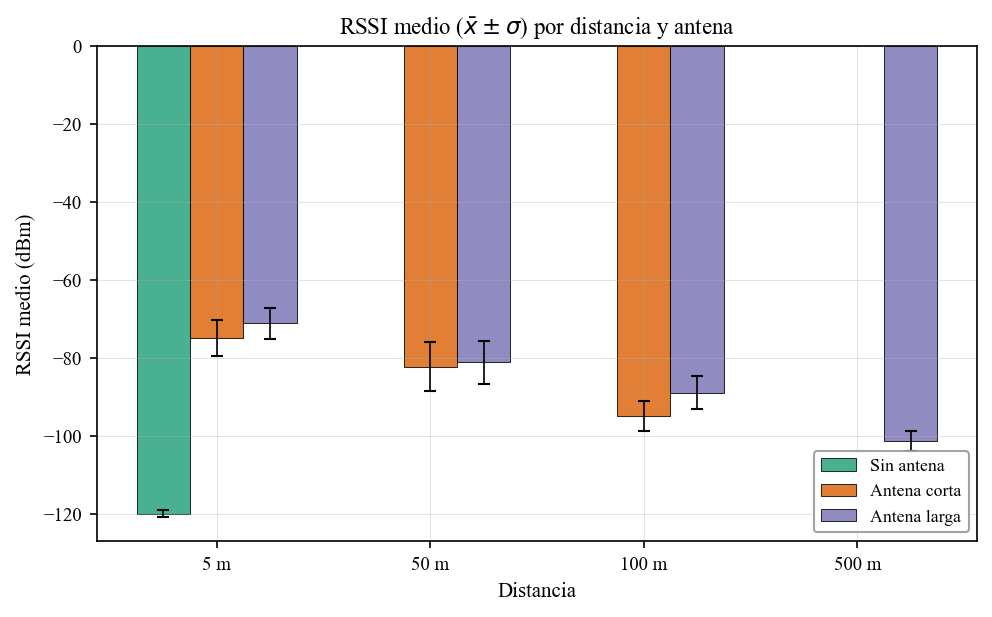

In [20]:
# --- Fig 13: Bar chart RSSI medio por configuración ---
fig, ax = plt.subplots(figsize=(6.5, 4))

bar_width = 0.25
x_pos = np.arange(len(DIST_ORDER))

for i, ant in enumerate(ANTENA_ORDER):
    means = []
    stds = []
    for dist in DIST_ORDER:
        sub = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]
        if sub.empty:
            means.append(np.nan)
            stds.append(0)
        else:
            means.append(sub["rssi"].mean())
            stds.append(sub["rssi"].std())
    ax.bar(x_pos + i * bar_width, means, bar_width, yerr=stds,
           color=ANTENA_COLORS[ant], edgecolor="black", linewidth=0.5,
           alpha=0.8, label=ANTENA_LABELS[ant],
           capsize=3, error_kw={"linewidth": 0.8})

ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels([f"{d} m" for d in DIST_ORDER])
ax.set_ylabel("RSSI medio (dBm)")
ax.set_xlabel("Distancia")
ax.set_title("RSSI medio ($\\bar{x} \\pm \\sigma$) por distancia y antena")
ax.legend()
plt.show()

## 14. RSSI con media móvil (smoothed time series)

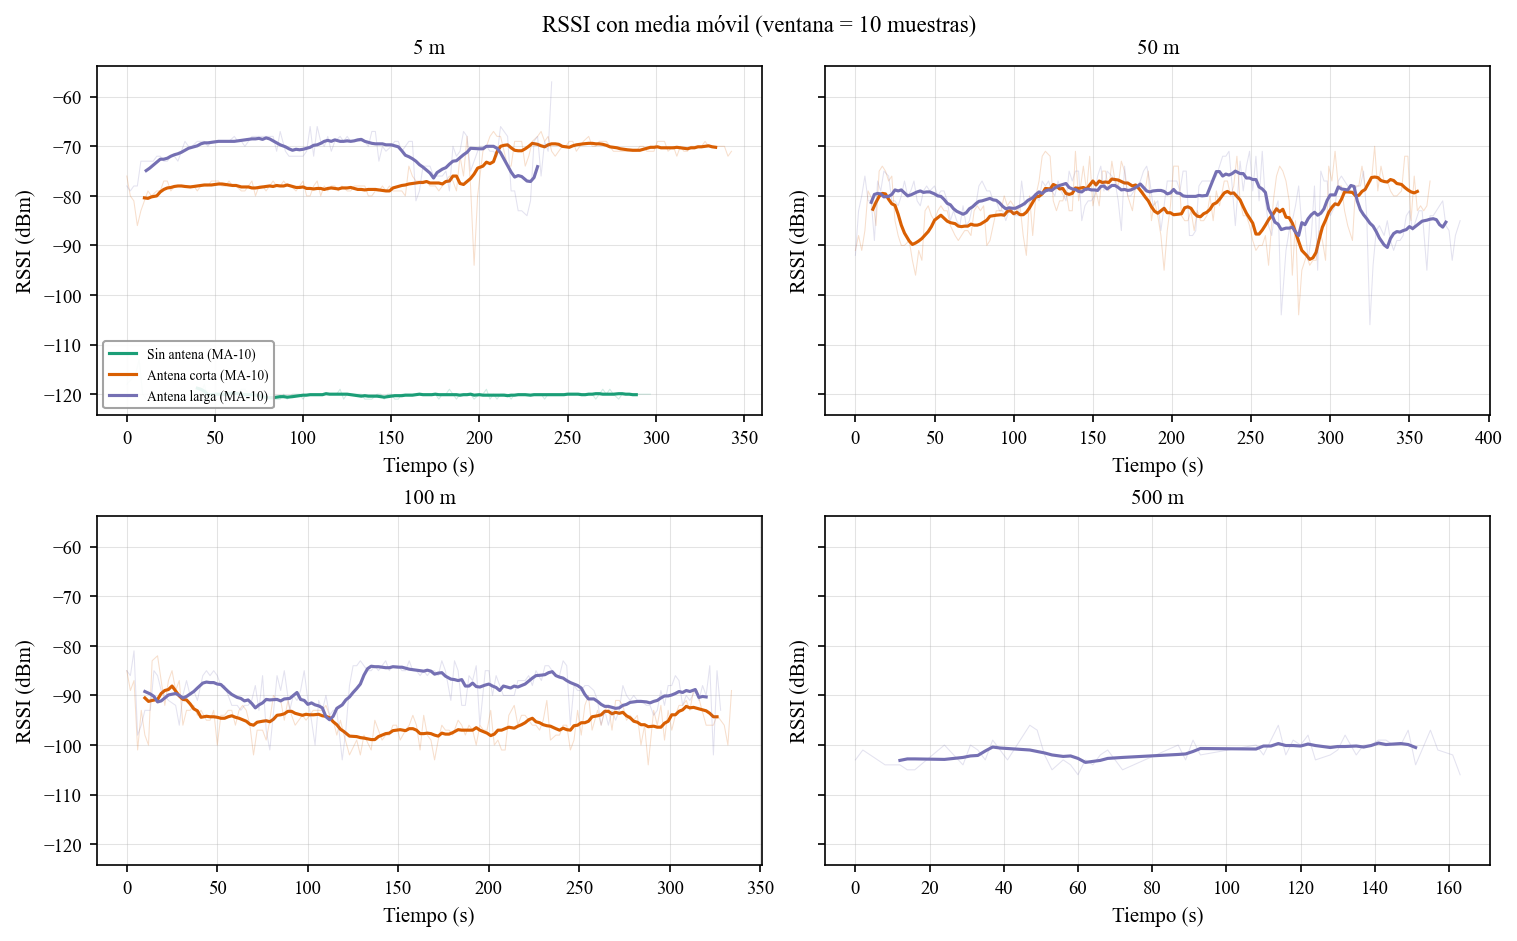

In [21]:
# --- Fig 14: Serie temporal con media móvil (ventana=10) ---
WINDOW = 10

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=True)
axes = axes.flatten()

for idx, dist in enumerate(DIST_ORDER):
    ax = axes[idx]
    sub_dist = df_ensayos[df_ensayos["distancia"] == dist]
    for ant in ANTENA_ORDER:
        sub = sub_dist[sub_dist["nombre"] == ant].sort_values("fecha")
        if sub.empty:
            continue
        t = (sub["fecha"] - sub["fecha"].iloc[0]).dt.total_seconds()
        rssi = sub["rssi"].values
        # Datos crudos
        ax.plot(t, rssi, color=ANTENA_COLORS[ant], alpha=0.2, linewidth=0.5)
        # Media móvil
        if len(rssi) >= WINDOW:
            ma = pd.Series(rssi).rolling(WINDOW, center=True).mean()
            ax.plot(t, ma, color=ANTENA_COLORS[ant], linewidth=1.5,
                    label=f"{ANTENA_LABELS[ant]} (MA-{WINDOW})")

    ax.set_title(f"{dist} m", fontsize=10)
    ax.set_ylabel("RSSI (dBm)")
    ax.set_xlabel("Tiempo (s)")
    if idx == 0:
        ax.legend(fontsize=6.5, loc="lower left")

fig.suptitle(f"RSSI con media móvil (ventana = {WINDOW} muestras)", fontsize=11, y=1.02)
plt.show()

## 15. Radar/Spider chart — Comparación multidimensional por antena

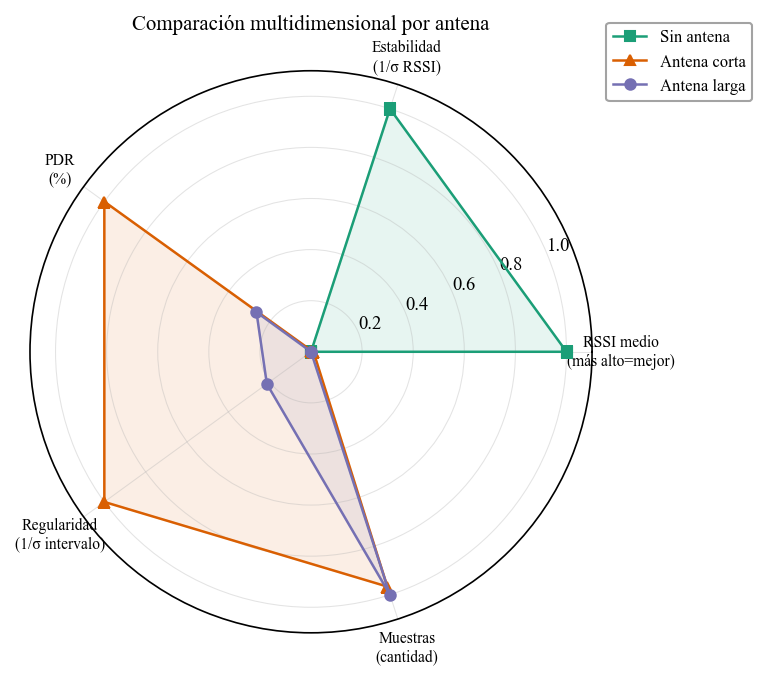

In [22]:
# --- Fig 15: Radar chart por tipo de antena (métricas normalizadas) ---
from matplotlib.patches import FancyBboxPatch

# Calcular métricas por antena (promediando distancias)
radar_data = {}
for ant in ANTENA_ORDER:
    sub = df_ensayos[df_ensayos["nombre"] == ant]
    tr = tasa_recepcion[tasa_recepcion["tipo_antena"] == ant]
    if sub.empty:
        continue
    radar_data[ant] = {
        "RSSI medio\n(más alto=mejor)": -sub["rssi"].mean(),          # invertido: mayor es mejor
        "Estabilidad\n(1/σ RSSI)": 1 / max(sub["rssi"].std(), 0.1),
        "PDR\n(%)": tr["pct_entrega"].mean() if not tr.empty else 0,
        "Regularidad\n(1/σ intervalo)": 1 / max(sub["delta_n1_seg"].std(), 0.01),
        "Muestras\n(cantidad)": len(sub),
    }

categories = list(list(radar_data.values())[0].keys())
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

for ant, metrics in radar_data.items():
    values = list(metrics.values())
    # Normalizar 0-1
    values_arr = np.array(values)
    all_vals = np.array([[m[k] for k in metrics] for m in radar_data.values()])
    mins = all_vals.min(axis=0)
    maxs = all_vals.max(axis=0)
    ranges = maxs - mins
    ranges[ranges == 0] = 1
    norm_values = ((values_arr - mins) / ranges).tolist()
    norm_values += norm_values[:1]

    ax.plot(angles, norm_values, ANTENA_MARKERS[ant] + "-", color=ANTENA_COLORS[ant],
            linewidth=1.2, label=ANTENA_LABELS[ant], markersize=5)
    ax.fill(angles, norm_values, color=ANTENA_COLORS[ant], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=7.5)
ax.set_ylim(0, 1.1)
ax.set_title("Comparación multidimensional por antena", fontsize=10, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
plt.show()

## 16. ECDF por distancia (subplots separados)

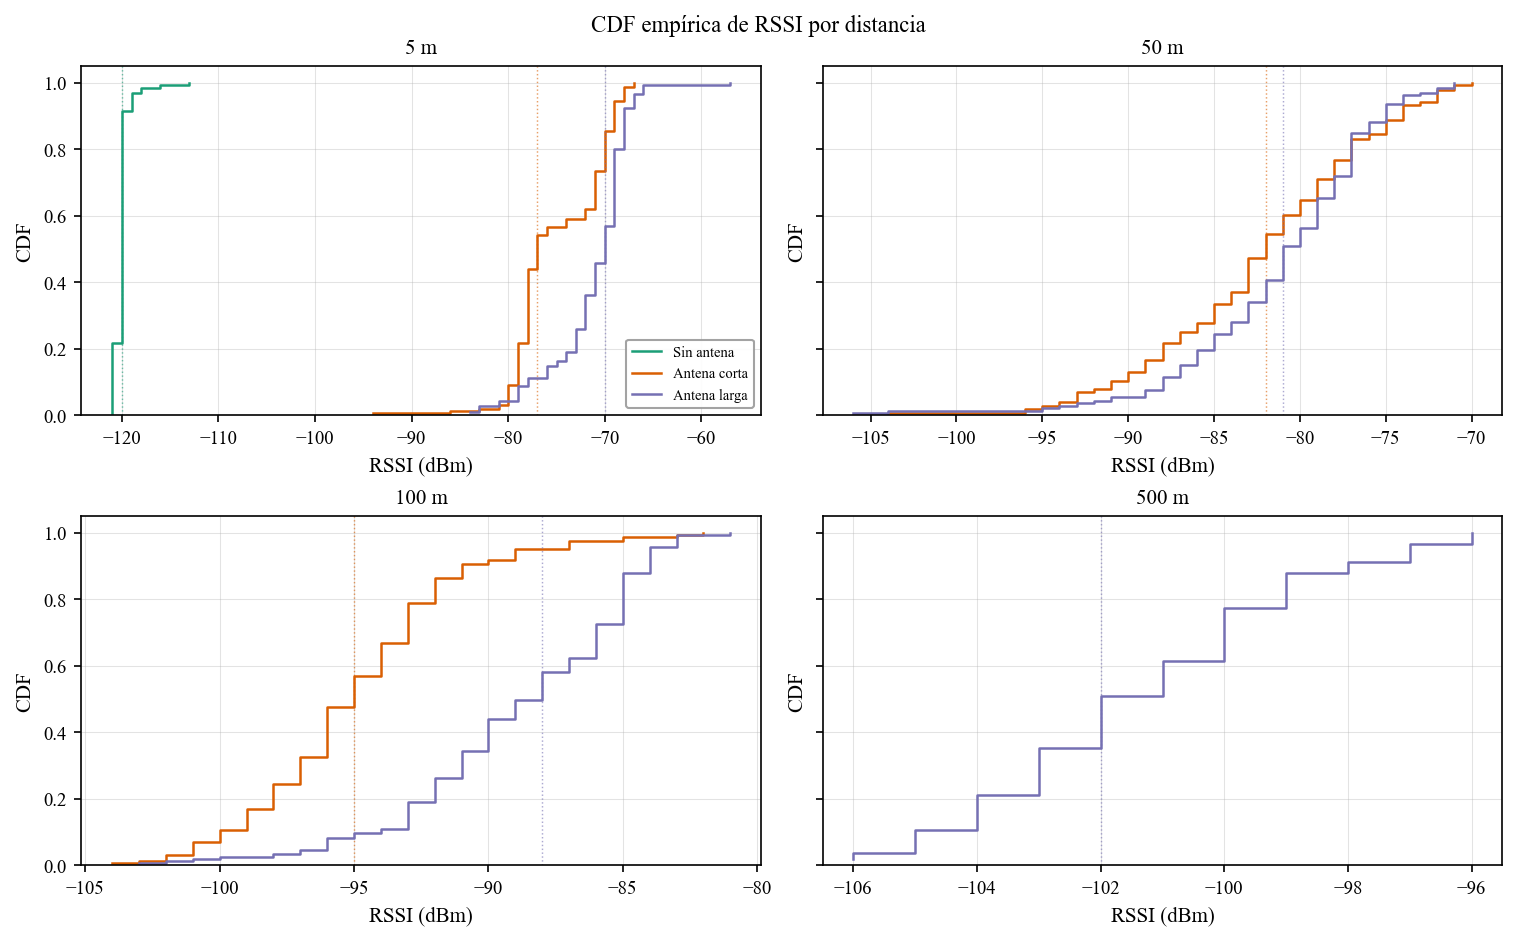

In [23]:
# --- Fig 16: ECDF por distancia (subplots) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False, sharey=True)
axes = axes.flatten()

for idx, dist in enumerate(DIST_ORDER):
    ax = axes[idx]
    sub_dist = df_ensayos[df_ensayos["distancia"] == dist]
    for ant in ANTENA_ORDER:
        sub = sub_dist[sub_dist["nombre"] == ant]
        if sub.empty:
            continue
        rssi_sorted = np.sort(sub["rssi"].values)
        ecdf = np.arange(1, len(rssi_sorted) + 1) / len(rssi_sorted)
        ax.step(rssi_sorted, ecdf, where="post", color=ANTENA_COLORS[ant],
                linewidth=1.2, label=ANTENA_LABELS[ant])
        # Marcar mediana
        med = np.median(rssi_sorted)
        ax.axvline(med, color=ANTENA_COLORS[ant], linestyle=":", linewidth=0.7, alpha=0.6)

    ax.set_title(f"{dist} m", fontsize=10)
    ax.set_xlabel("RSSI (dBm)")
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1.05)
    if idx == 0:
        ax.legend(fontsize=7)

fig.suptitle("CDF empírica de RSSI por distancia", fontsize=11, y=1.02)
plt.show()

## 17. Heatmap — Desviación estándar del RSSI

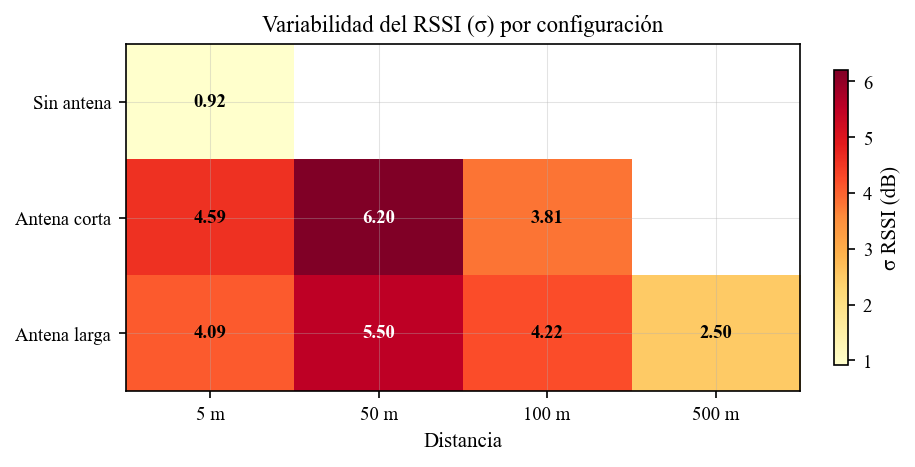

In [24]:
# --- Fig 17: Heatmap de desviación estándar RSSI ---
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(pivot_std.values, cmap="YlOrRd", aspect="auto")
cbar = fig.colorbar(im, ax=ax, shrink=0.85, label="σ RSSI (dB)")

for i in range(pivot_std.shape[0]):
    for j in range(pivot_std.shape[1]):
        val = pivot_std.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if val > 5 else "black")

ax.set_xticks(range(len(DIST_ORDER)))
ax.set_xticklabels([f"{d} m" for d in DIST_ORDER])
ax.set_yticks(range(len(ANTENA_ORDER)))
ax.set_yticklabels([ANTENA_LABELS[a] for a in ANTENA_ORDER])
ax.set_xlabel("Distancia")
ax.set_title("Variabilidad del RSSI (σ) por configuración")
plt.show()

## 18. PDR vs RSSI medio (scatter con anotaciones)

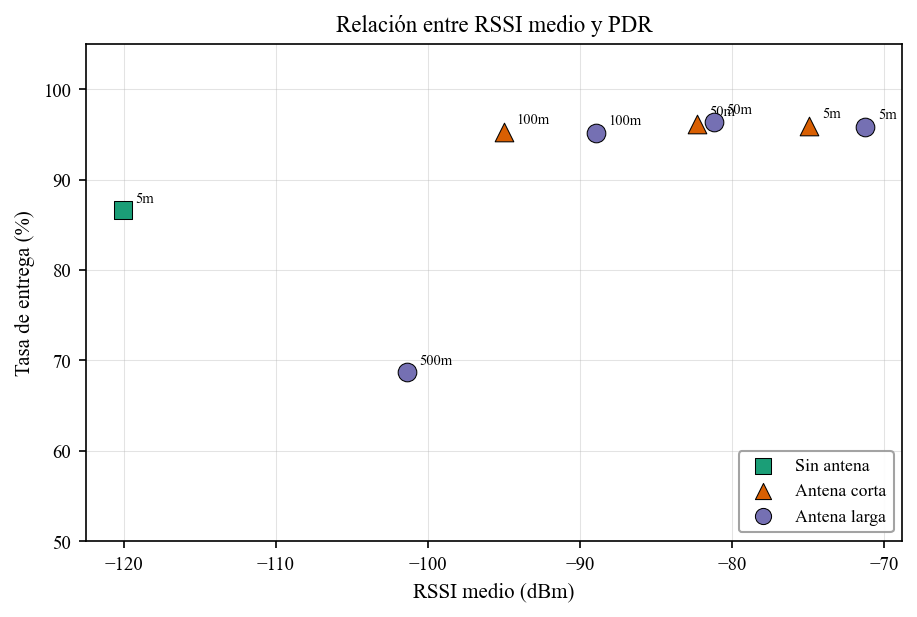

In [25]:
# --- Fig 18: PDR vs RSSI medio (scatter) ---
fig, ax = plt.subplots(figsize=(6, 4))

for _, row in tasa_recepcion.iterrows():
    ant = row["tipo_antena"]
    dist = row["distancia_m"]
    ax.scatter(row["rssi_prom"], row["pct_entrega"],
               color=ANTENA_COLORS.get(ant, "gray"),
               marker=ANTENA_MARKERS.get(ant, "o"),
               s=80, edgecolors="black", linewidth=0.5, zorder=5)
    ax.annotate(f"{dist}m", (row["rssi_prom"], row["pct_entrega"]),
                textcoords="offset points", xytext=(6, 4), fontsize=7)

# Leyenda
for ant in ANTENA_ORDER:
    ax.scatter([], [], color=ANTENA_COLORS[ant], marker=ANTENA_MARKERS[ant],
               s=60, edgecolors="black", linewidth=0.5, label=ANTENA_LABELS[ant])

ax.set_xlabel("RSSI medio (dBm)")
ax.set_ylabel("Tasa de entrega (%)")
ax.set_title("Relación entre RSSI medio y PDR")
ax.legend(loc="lower right")
ax.set_ylim(50, 105)
plt.show()

## 19. Strip plot (dot plot) — Todos los puntos RSSI por configuración

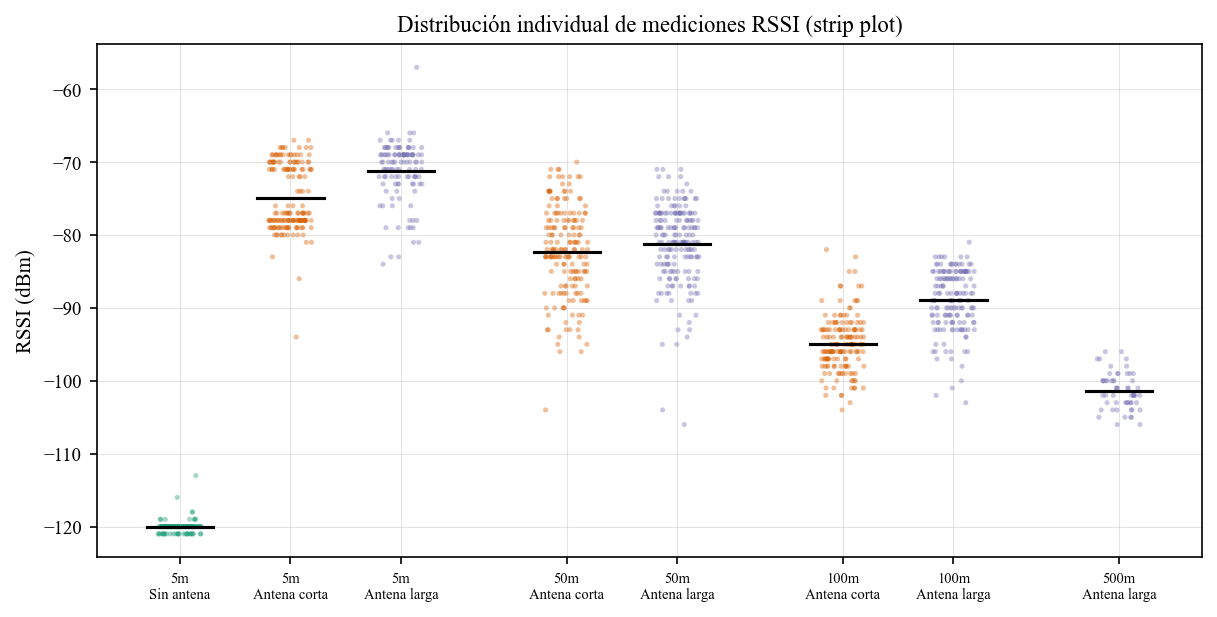

In [26]:
# --- Fig 19: Strip plot (jittered dot plot) ---
fig, ax = plt.subplots(figsize=(8, 4))

pos_idx = 0
tick_positions = []
tick_labels = []

for dist in DIST_ORDER:
    antenas_in_dist = [a for a in ANTENA_ORDER if a in df_ensayos[df_ensayos["distancia"] == dist]["nombre"].unique()]
    for ant in antenas_in_dist:
        sub = df_ensayos[(df_ensayos["distancia"] == dist) & (df_ensayos["nombre"] == ant)]
        jitter = np.random.default_rng(42).uniform(-0.2, 0.2, size=len(sub))
        ax.scatter(pos_idx + jitter, sub["rssi"], s=6, alpha=0.4,
                   color=ANTENA_COLORS[ant], edgecolors="none")
        # Media
        ax.plot([pos_idx - 0.3, pos_idx + 0.3], [sub["rssi"].mean()] * 2,
                color="black", linewidth=1.5, zorder=10)
        tick_positions.append(pos_idx)
        tick_labels.append(f"{dist}m\n{ANTENA_LABELS[ant]}")
        pos_idx += 1
    pos_idx += 0.5  # gap entre distancias

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=7)
ax.set_ylabel("RSSI (dBm)")
ax.set_title("Distribución individual de mediciones RSSI (strip plot)")
plt.show()

## 20. Tabla resumen estadístico (estilo paper)

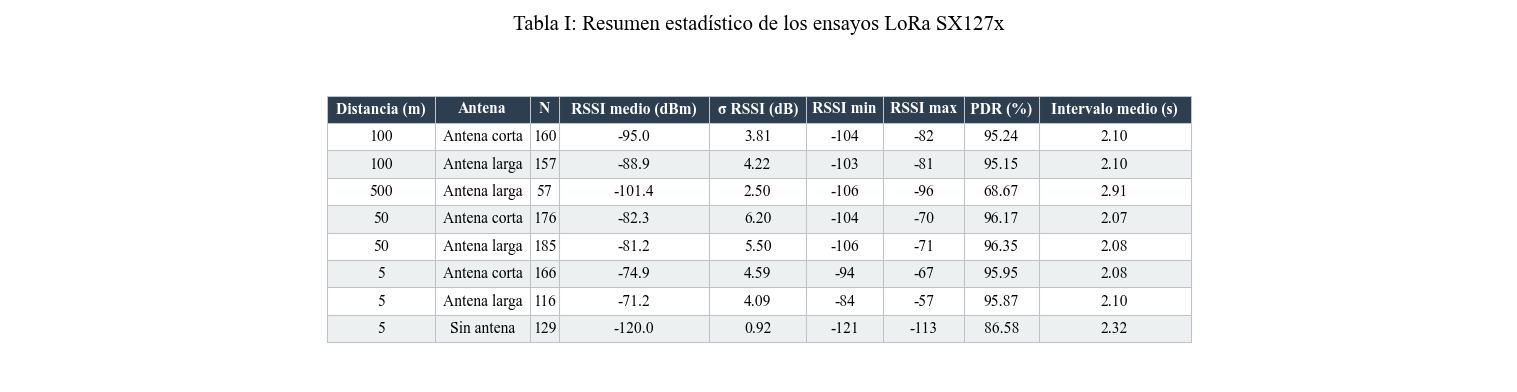

In [27]:
# --- Fig 20: Tabla resumen renderizada como figura (para insertar en paper) ---
summary_rows = []
for archivo in sorted(df_ensayos["archivo"].unique()):
    sub = df_ensayos[df_ensayos["archivo"] == archivo]
    dist = sub["distancia"].iloc[0]
    ant = sub["nombre"].iloc[0]
    tr = tasa_recepcion[tasa_recepcion["archivo"] == archivo]
    pdr = tr["pct_entrega"].values[0] if not tr.empty else "-"
    summary_rows.append({
        "Distancia (m)": dist,
        "Antena": ANTENA_LABELS.get(ant, ant),
        "N": len(sub),
        "RSSI medio (dBm)": f"{sub['rssi'].mean():.1f}",
        "σ RSSI (dB)": f"{sub['rssi'].std():.2f}",
        "RSSI min": sub["rssi"].min(),
        "RSSI max": sub["rssi"].max(),
        "PDR (%)": pdr,
        "Intervalo medio (s)": f"{sub['delta_n1_seg'].mean():.2f}",
    })

df_summary = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis("off")
table = ax.table(
    cellText=df_summary.values,
    colLabels=df_summary.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.auto_set_column_width(col=list(range(len(df_summary.columns))))

# Estilo header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2c3e50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#ecf0f1")
    cell.set_edgecolor("#bdc3c7")
    cell.set_linewidth(0.5)

ax.set_title("Tabla I: Resumen estadístico de los ensayos LoRa SX127x", fontsize=10, pad=15)
plt.show()